# 04. Exploratory Data Analysis - Pandas

## 04.1. Importação das bibliotecas

### 04.1.1. Importando as bibliotecas nativas do Python

In [1]:
import sys

### 04.1.2. Importando as bibliotecas de terceiros

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display, HTML

### 04.1.3. Importando os módulos locais do projeto

In [3]:
sys.path.append('..')
import functions.fn_charts_pandas as fn_charts_pandas
import functions.fn_stats_pandas as fn_stats_pandas
import params.consts as consts

## 04.2. Visão geral dos dados

### 04.2.1. Habilitando a exibição de todas as colunas e linhas

In [4]:
pd.set_option('display.max_columns', None); pd.set_option('display.max_rows', None)

### 04.2.2. Armazenando o dataset em uma variável

In [5]:
df = pd.read_parquet(consts.DATASET_CLEAN_PANDAS)

### 04.2.3. Visualizando a quantidade de linhas e colunas do dataset

In [6]:
df.shape

(440832, 11)

### 04.2.4. Exibindo o dataset

In [7]:
df.head(5)

,idade,sexo,total_gasto,assinatura,duracao_contrato,tempo_como_cliente,frequencia_uso,ligacoes_callcenter,dias_atraso,meses_ultima_interacao,cancelou
0,30.0,Female,932.0,Standard,Annual,39.0,14.0,5.0,18.0,17.0,1.0
1,65.0,Female,557.0,Basic,Monthly,49.0,1.0,10.0,8.0,6.0,1.0
2,55.0,Female,185.0,Basic,Quarterly,14.0,4.0,6.0,18.0,3.0,1.0
3,58.0,Male,396.0,Standard,Monthly,38.0,21.0,7.0,7.0,29.0,1.0
4,23.0,Male,617.0,Basic,Monthly,32.0,20.0,5.0,8.0,20.0,1.0


### 04.2.5. Visualizando os detalhes do dataset

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440832 entries, 0 to 440831
Data columns (total 11 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   idade                   440832 non-null  float64
 1   sexo                    440832 non-null  object 
 2   total_gasto             440832 non-null  float64
 3   assinatura              440832 non-null  object 
 4   duracao_contrato        440832 non-null  object 
 5   tempo_como_cliente      440832 non-null  float64
 6   frequencia_uso          440832 non-null  float64
 7   ligacoes_callcenter     440832 non-null  float64
 8   dias_atraso             440832 non-null  float64
 9   meses_ultima_interacao  440832 non-null  float64
 10  cancelou                440832 non-null  float64
dtypes: float64(8), object(3)
memory usage: 37.0+ MB


### 04.2.6. Visualizando as estatísticas das colunas numéricas

In [9]:
fn_stats_pandas.describe(df)

,idade,total_gasto,tempo_como_cliente,frequencia_uso,ligacoes_callcenter,dias_atraso,meses_ultima_interacao,cancelou
count,440832.00,440832.00,440832.00,440832.00,440832.00,440832.00,440832.00,440832.00
mean,39.37,631.62,31.26,15.81,3.60,12.97,14.48,0.57
std,12.44,240.80,17.26,8.59,3.07,8.26,8.60,0.50
min,18.00,100.00,1.00,1.00,0.00,0.00,1.00,0.00
25%,29.00,480.00,16.00,9.00,1.00,6.00,7.00,0.00
50%,39.00,661.00,32.00,16.00,3.00,12.00,14.00,1.00
75%,48.00,830.00,46.00,23.00,6.00,19.00,22.00,1.00
max,65.00,1000.00,60.00,30.00,10.00,30.00,30.00,1.00


### 04.2.7. Visualizando as estatísticas da colunas categóricas

In [10]:
df.describe(exclude = 'number')

,sexo,assinatura,duracao_contrato
count,440832,440832,440832
unique,2,3,3
top,Male,Standard,Annual
freq,250252,149128,177198


### 04.2.8. Verificando os valores nulos das colunas

In [11]:
df.isnull().sum()

idade                     0
sexo                      0
total_gasto               0
assinatura                0
duracao_contrato          0
tempo_como_cliente        0
frequencia_uso            0
ligacoes_callcenter       0
dias_atraso               0
meses_ultima_interacao    0
cancelou                  0
dtype: int64

### 04.2.9. Verificando os valores distintos das colunas

In [12]:
df.nunique()

idade                        48
sexo                          2
total_gasto               68363
assinatura                    3
duracao_contrato              3
tempo_como_cliente           60
frequencia_uso               30
ligacoes_callcenter          11
dias_atraso                  31
meses_ultima_interacao       30
cancelou                      2
dtype: int64

### 04.2.10. Verificando os registos totalmente duplicados

In [13]:
len(df) - len(df.drop_duplicates())

0

### 04.2.11. Verificando a quantidade de colunas numéricas, categóricas e de data

In [14]:
num_cols = df.select_dtypes(include = 'number').shape[1]

categ_cols = df.select_dtypes(include = 'object').shape[1]

date_cols = df.select_dtypes(include = ['datetime64[ns]', 'datetime64[ns, UTC]']).shape[1]

print(f'- Numeric Columns: {num_cols}\n- Categoric Columns: {categ_cols}\n- Date Columns: {date_cols}')

- Numeric Columns: 8
- Categoric Columns: 3
- Date Columns: 0


## 04.3. Análise exploratória dos dados

### 04.3.1. Criando um histograma para entender a distribuição dos dados das colunas

- Gráfico: Histograma.


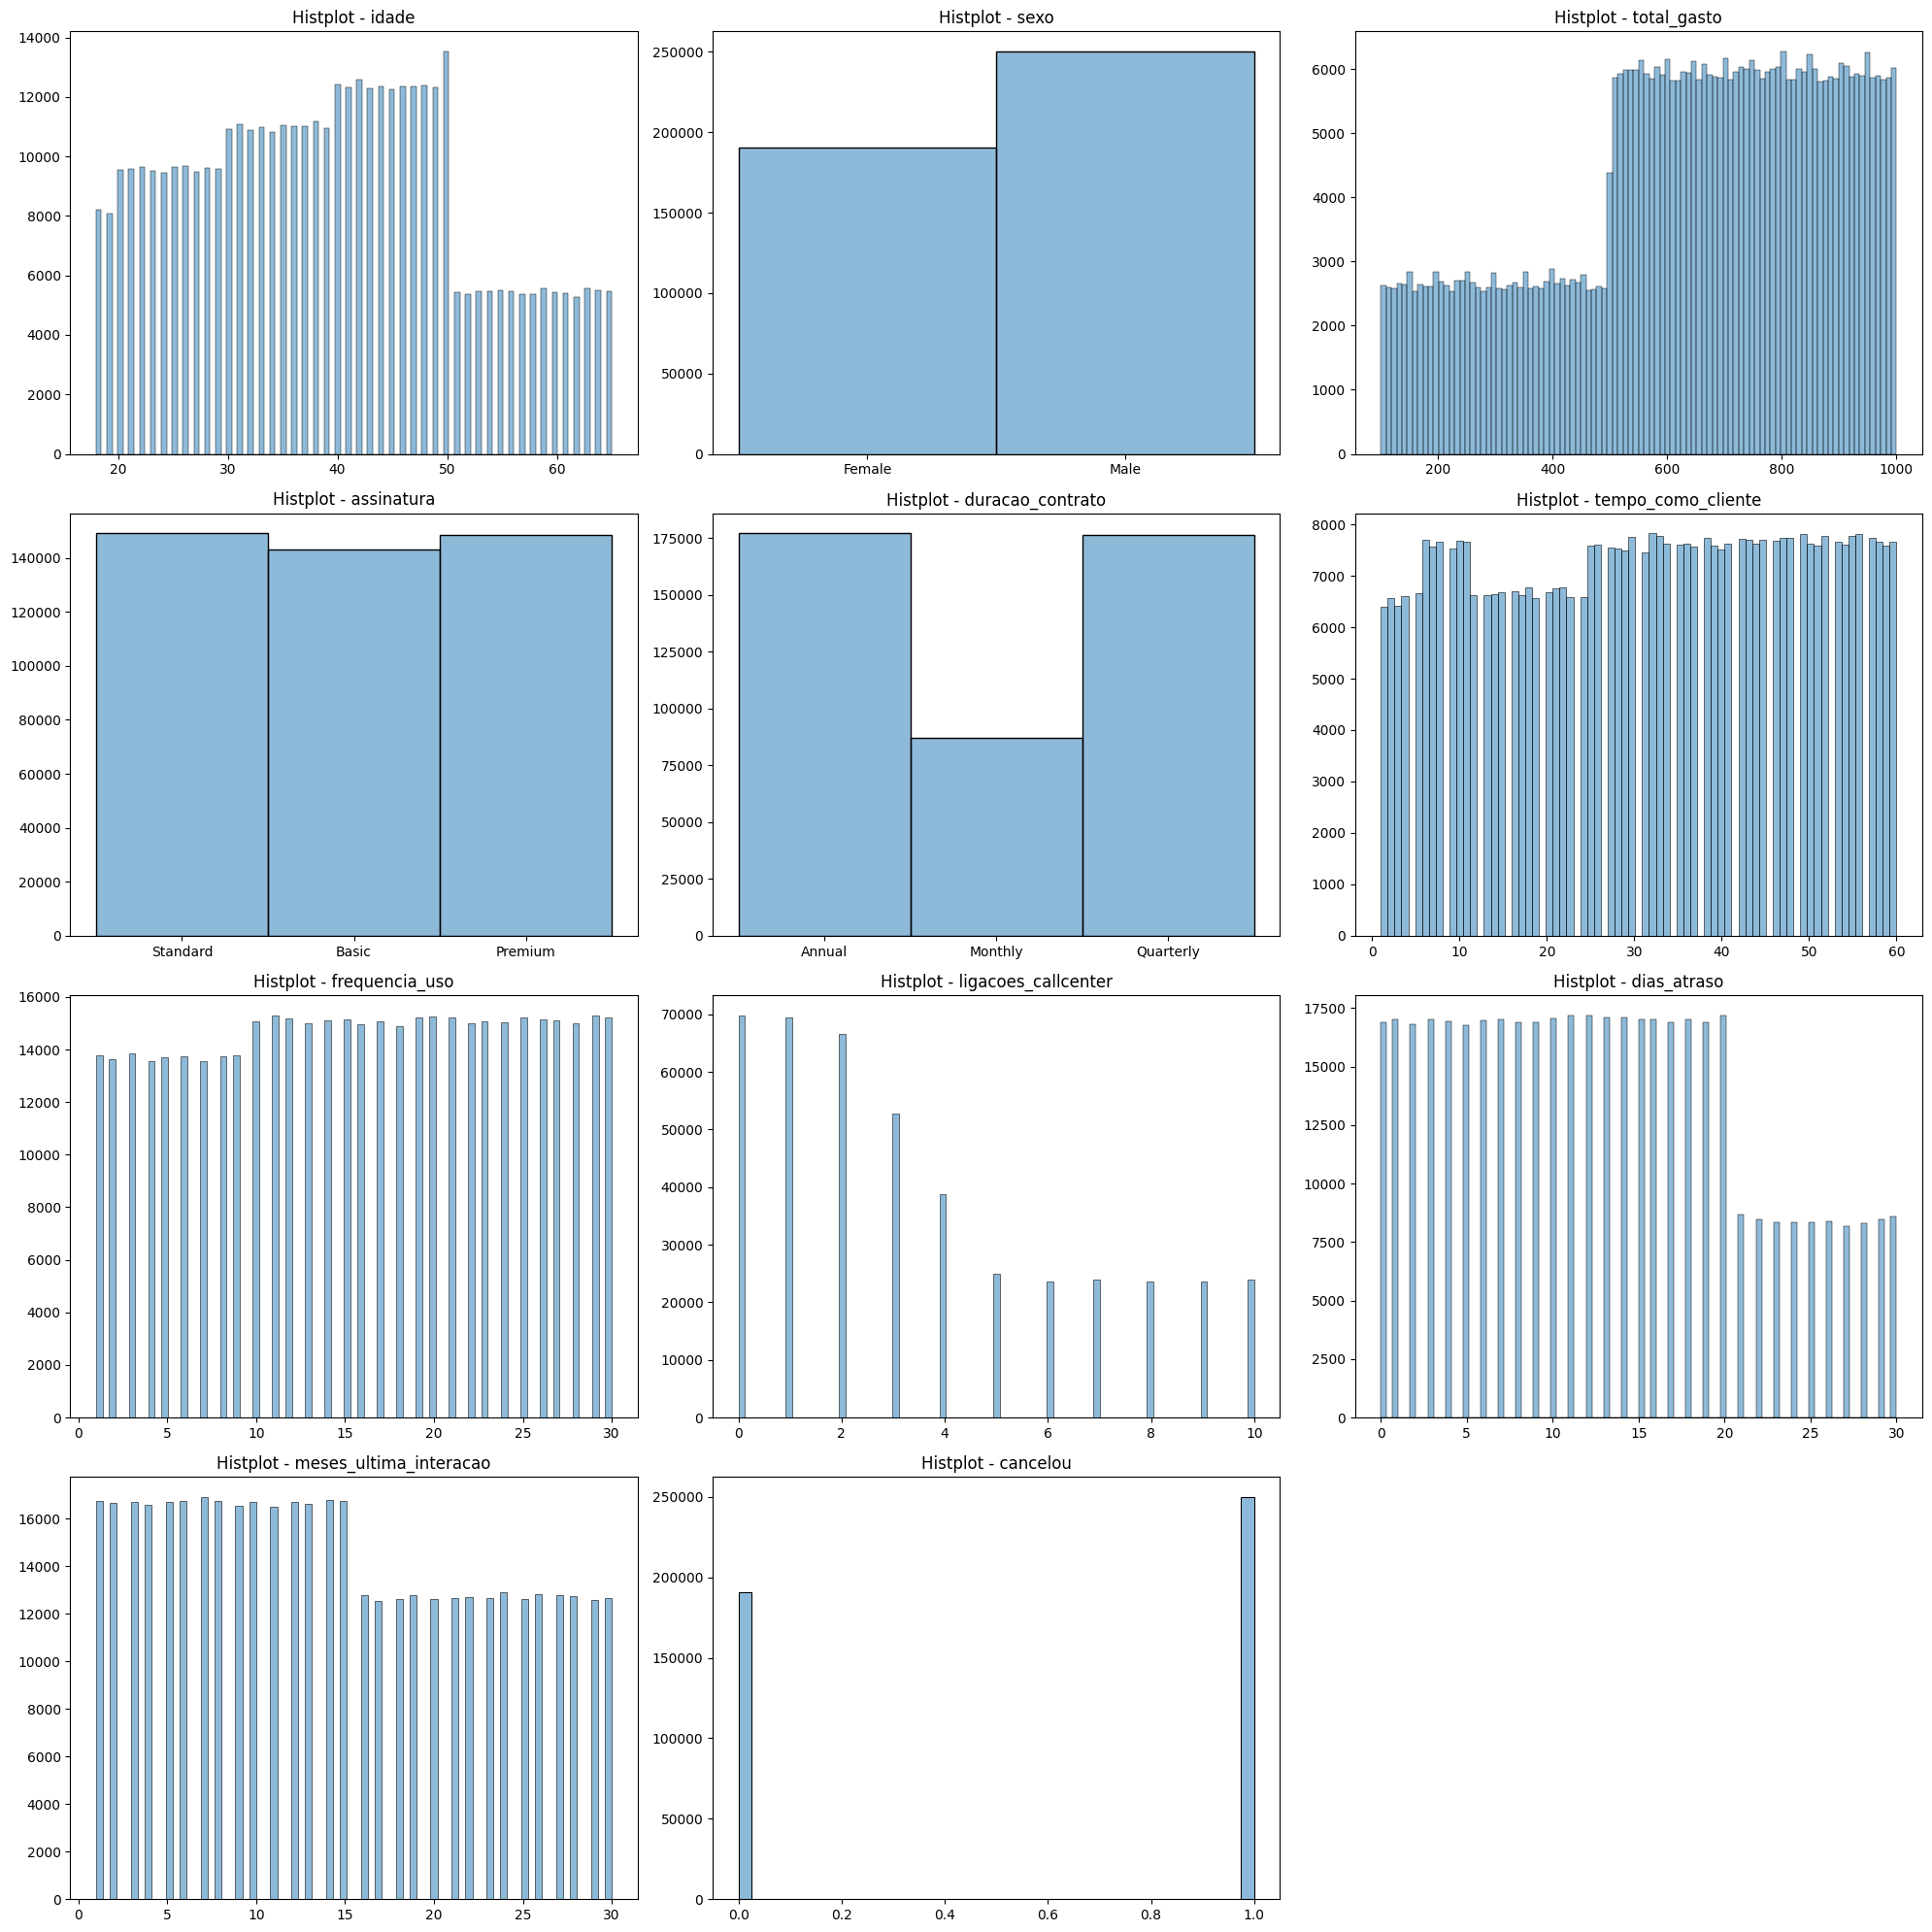

In [15]:
print('- Gráfico: Histograma.')

fn_charts_pandas.histplot(df, df.columns)

plt.savefig(f'../images/outputs/charts/pandas/nb04_histplot.png', format = 'png', dpi = 75, bbox_inches = 'tight', transparent = True)

plt.show()

### 04.3.2. Criando gráficos de dispersão para entender inicialmente a distribuição dos dados de acordo com colunas com alta cardinalidade, amplitude e escala contínua

- Gráfico: Gráfico de Dispersão.

- Scatter Column: idade.



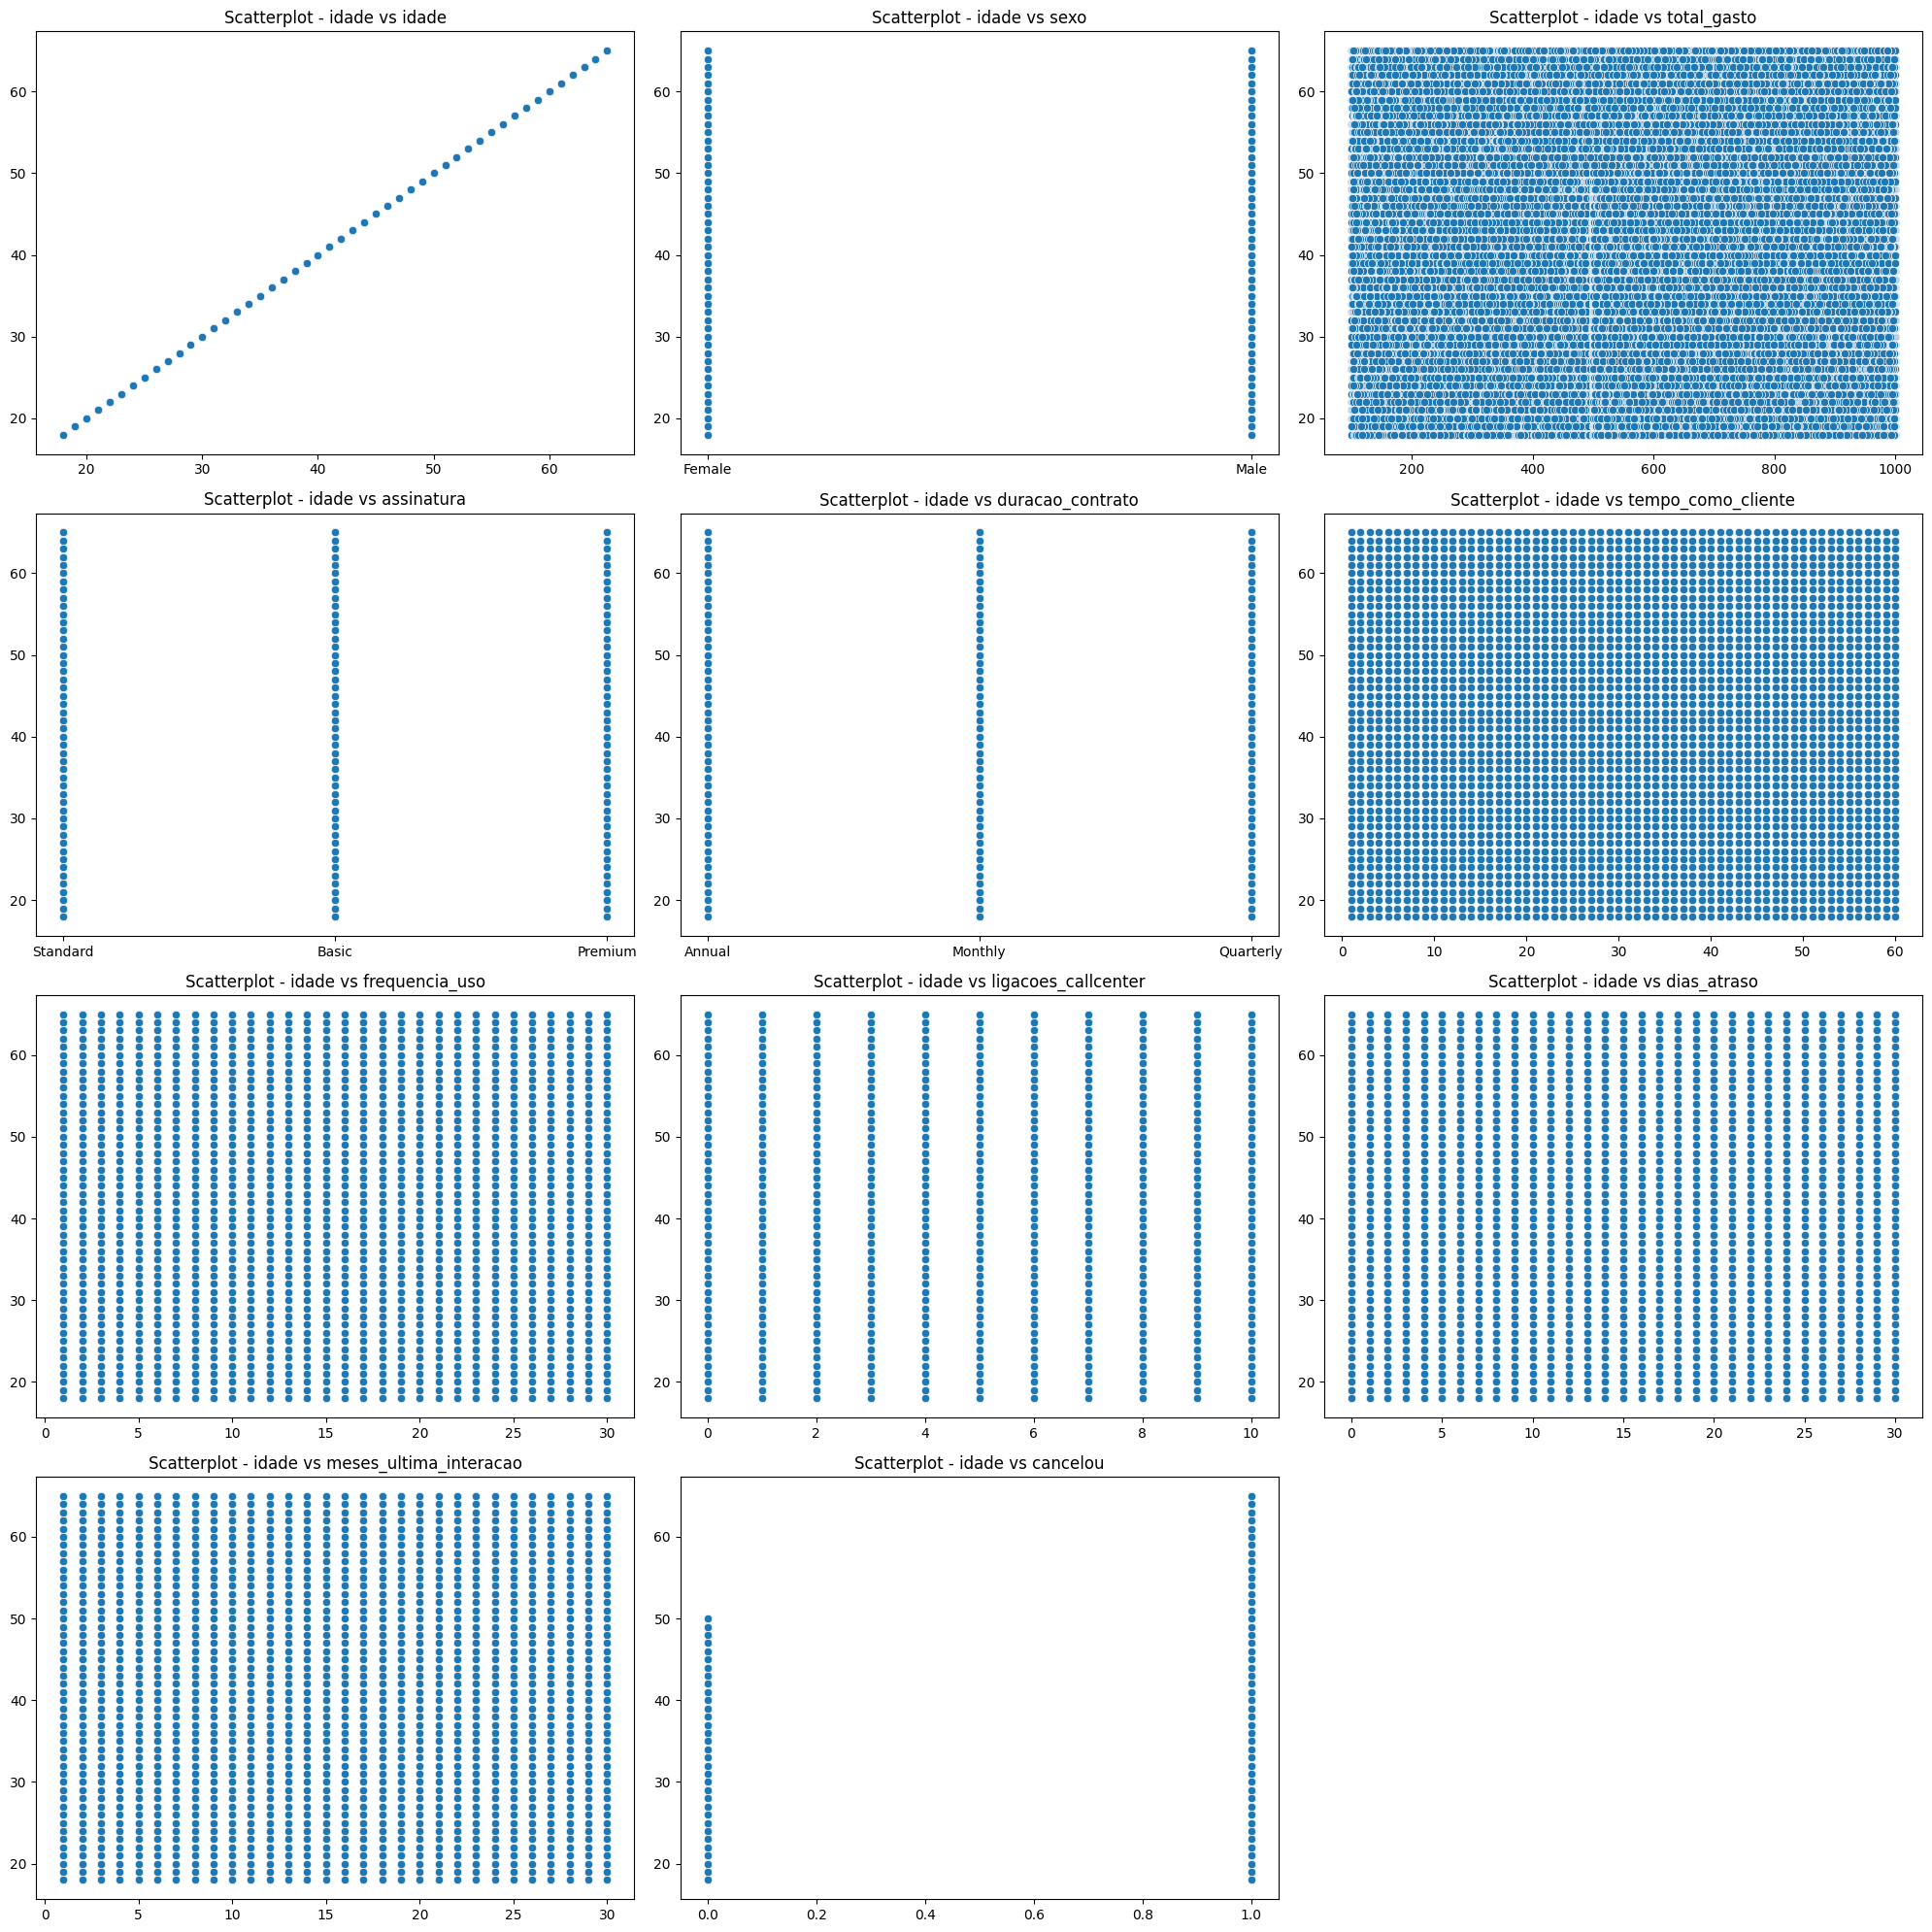

- Gráfico: Gráfico de Dispersão.

- Scatter Column: total_gasto.



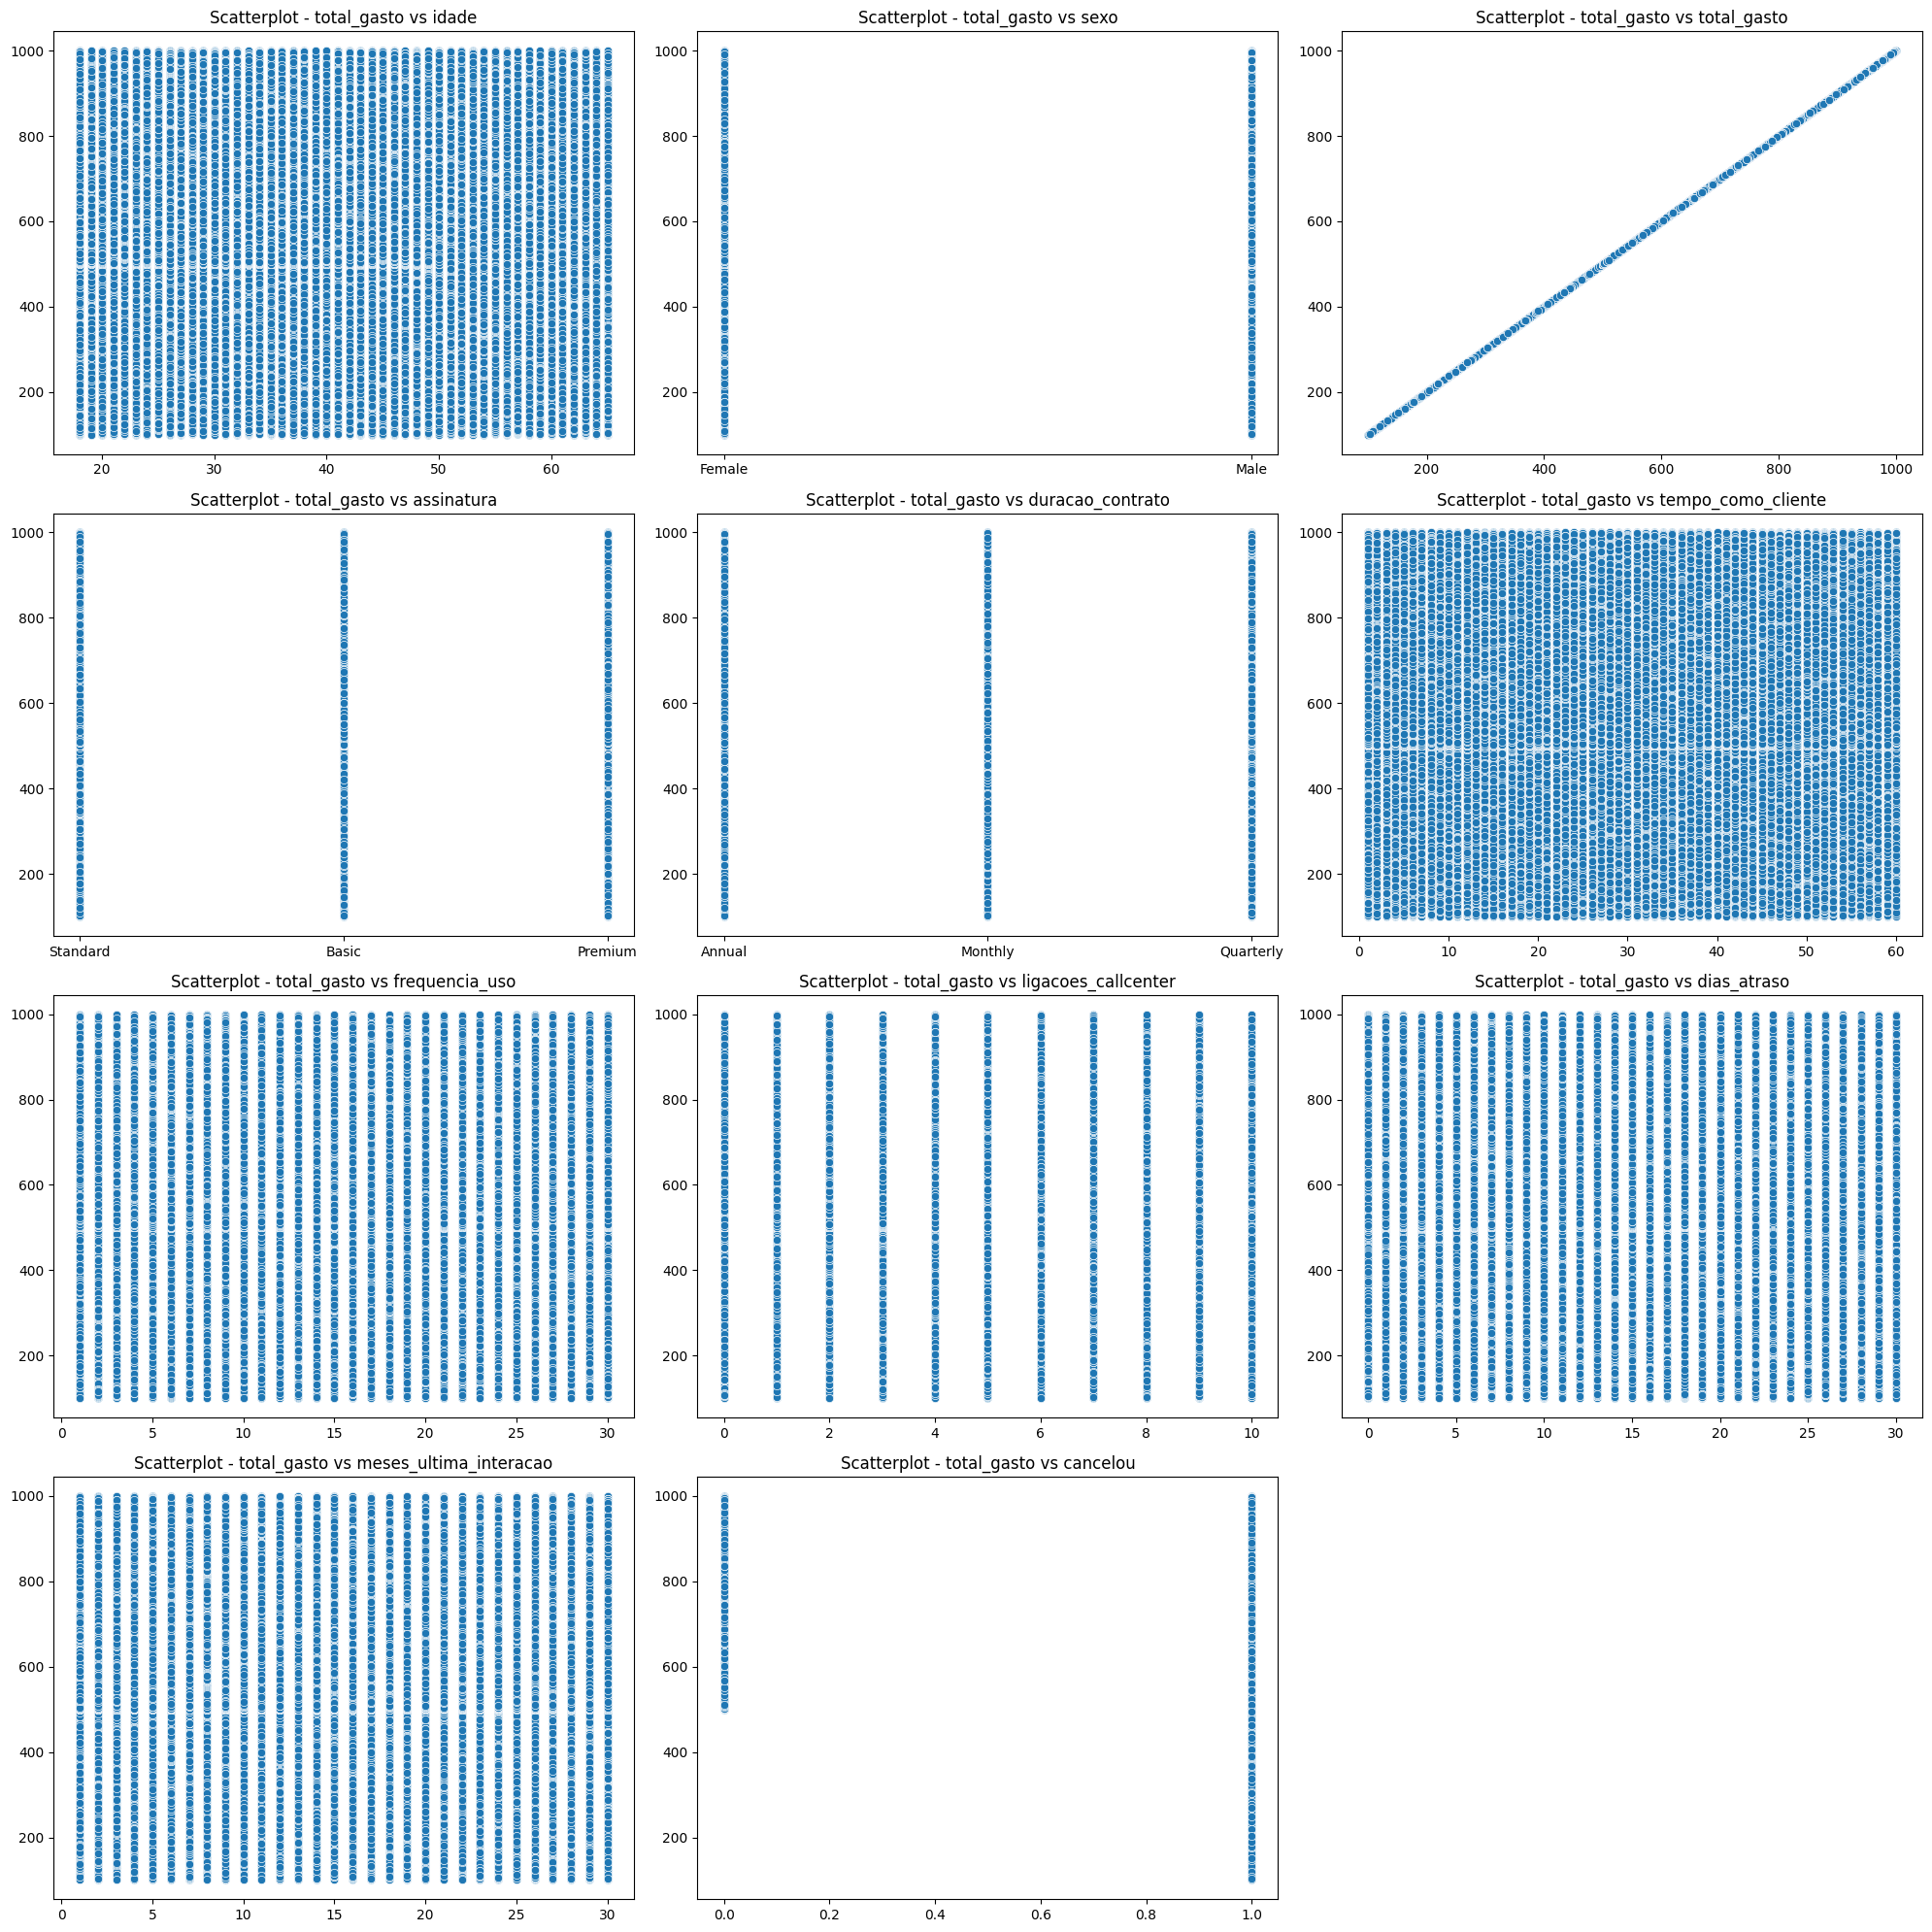

In [16]:
scatter_columns = ['idade', 'total_gasto']

for i in scatter_columns:

    print('- Gráfico: Gráfico de Dispersão.\n')

    print(f'- Scatter Column: {i}.\n')

    fn_charts_pandas.scatterplot(df, df.columns, i)

    plt.savefig(f'../images/outputs/charts/pandas/nb04_scatterplot_{i.lower()}.png', format = 'png', dpi = 75, bbox_inches = 'tight', transparent = True)

    plt.show()

### 04.3.3. Definindo as colunas com potencial de gerar os insights mais relevantes

In [17]:
hue_columns = [
    'cancelou',
]

### 04.3.4. Criando histogramas de acordo com as hue columns para extrair insights

- Gráfico: Histograma.

- Hue Column: cancelou.


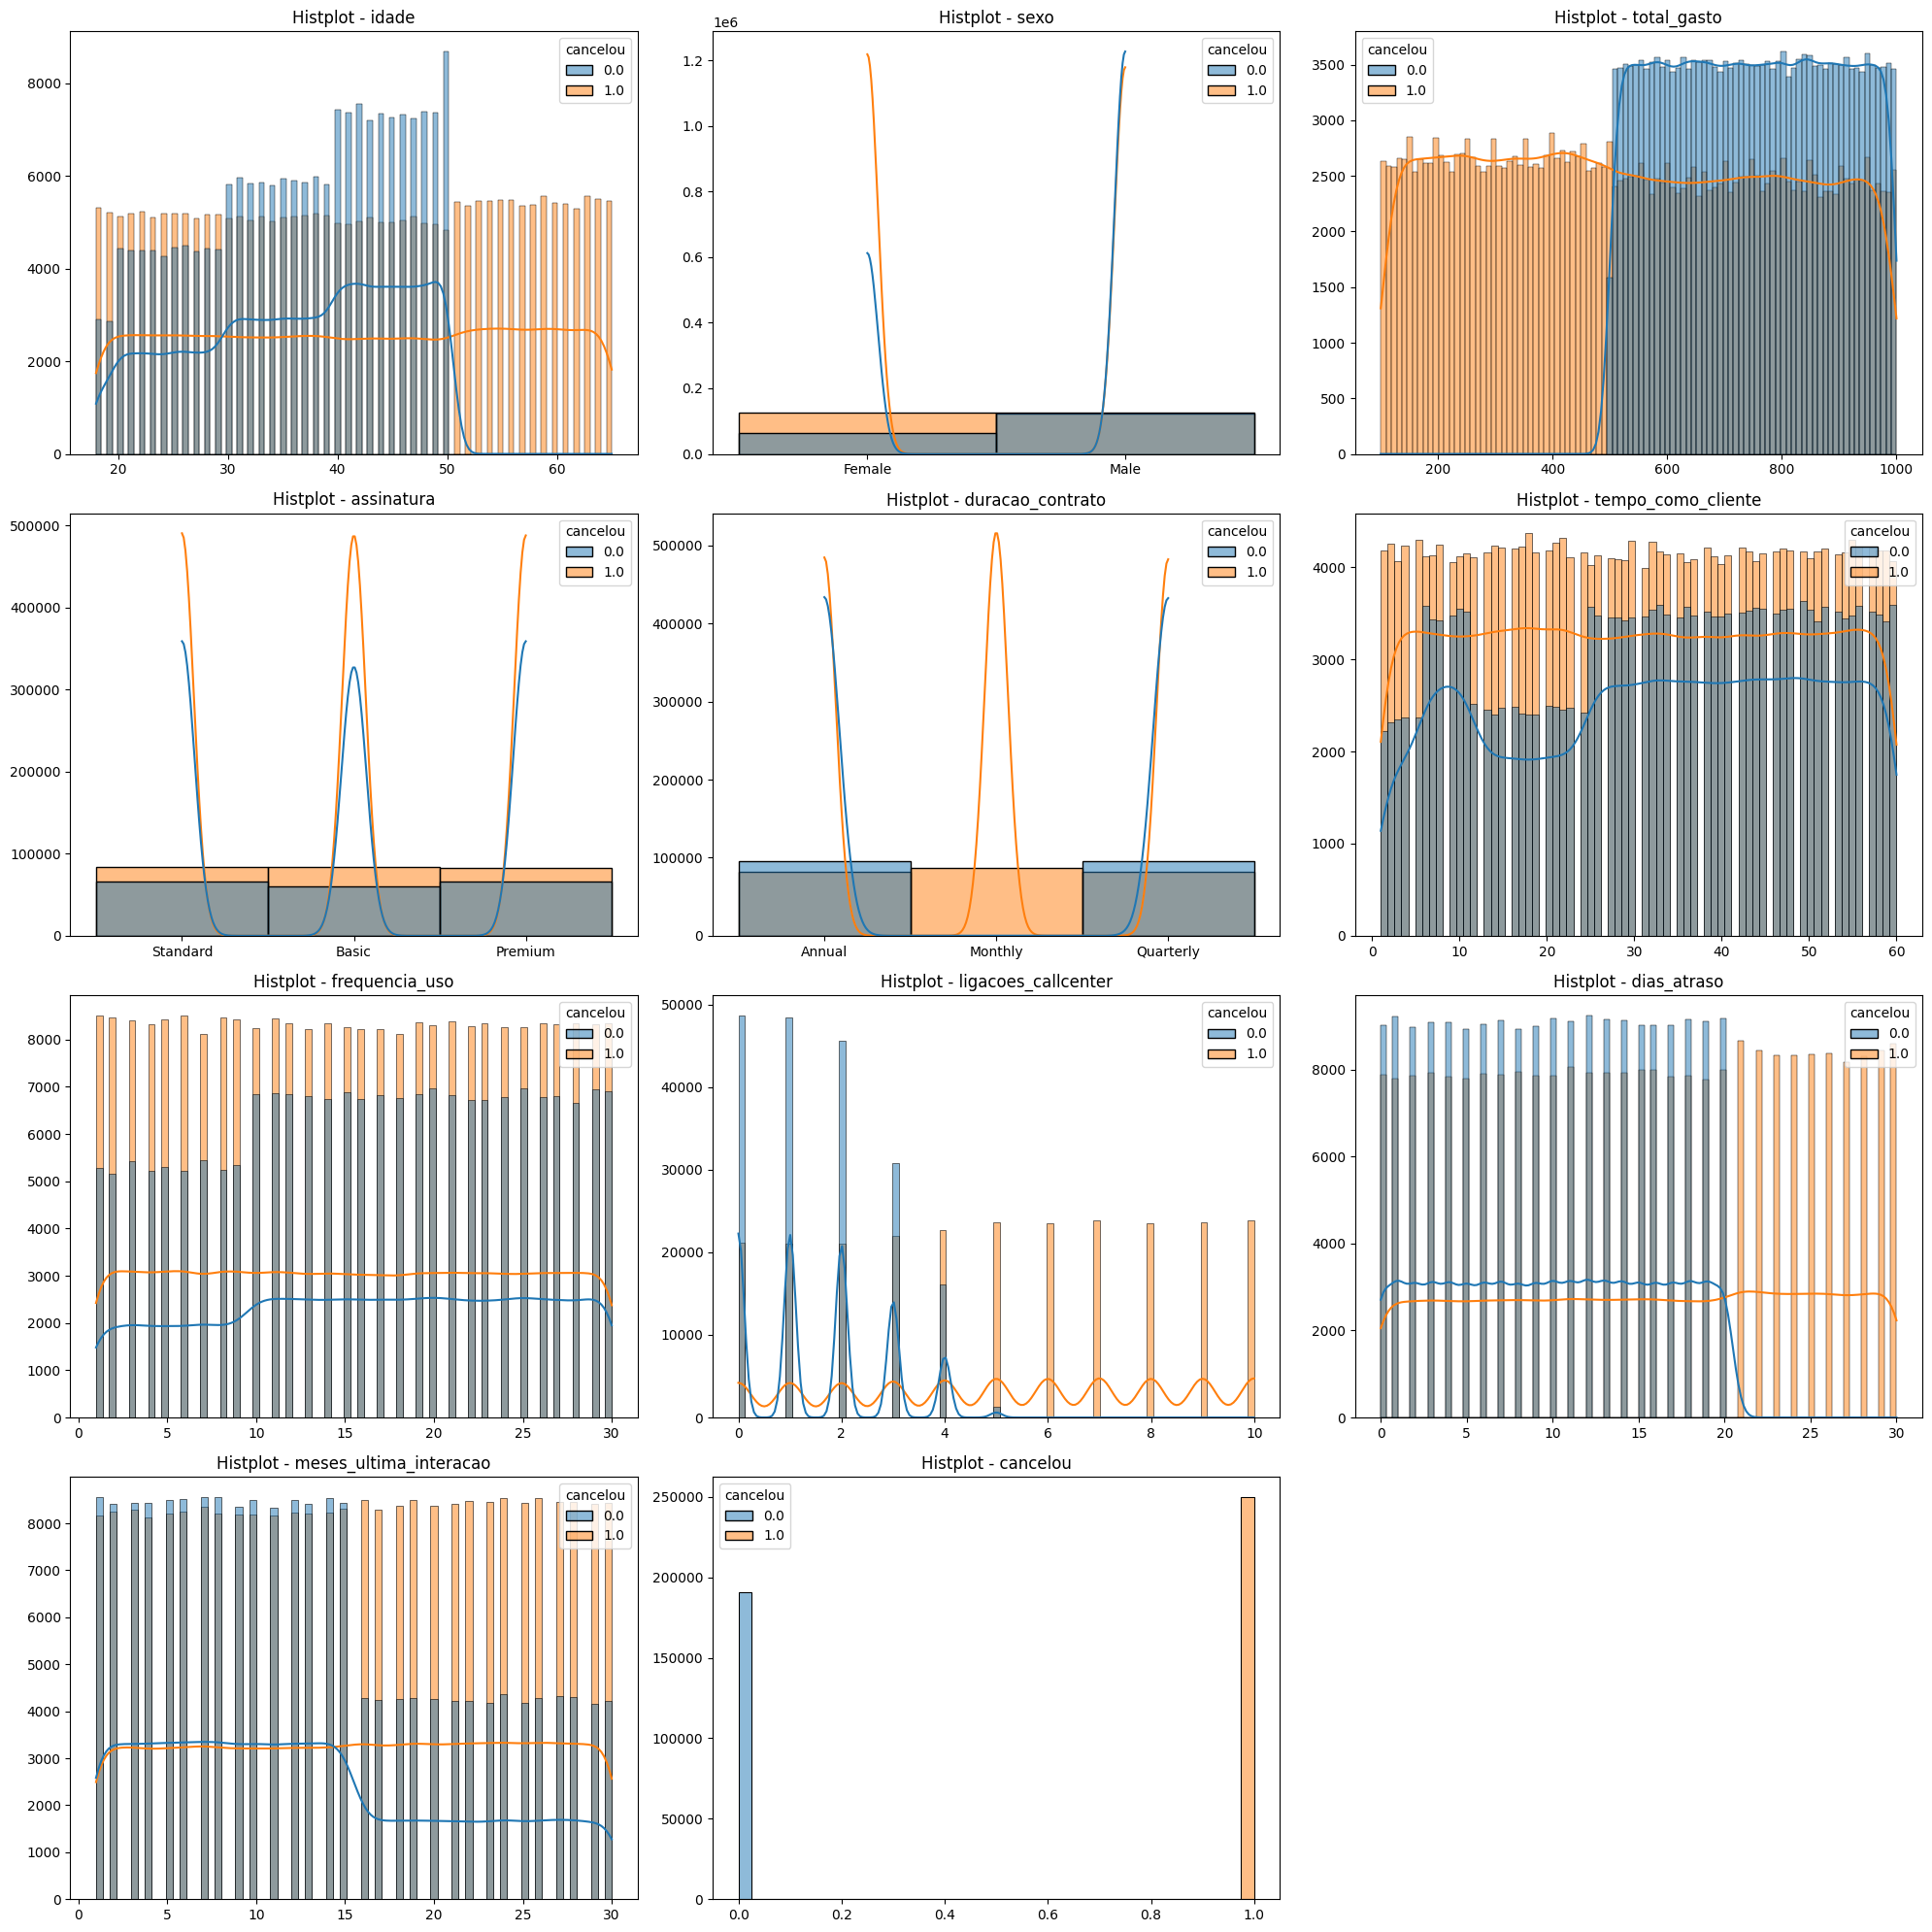

In [18]:
for i in hue_columns:

    print('- Gráfico: Histograma.\n')

    print(f'- Hue Column: {i}.')

    fn_charts_pandas.histplot(df, df.columns, i, kde = True)

    plt.savefig(f'../images/outputs/charts/pandas/nb04_histplot_{i.lower()}.png', format = 'png', dpi = 75, bbox_inches = 'tight', transparent = True)

    plt.show()

### 04.3.5. Listando os insights encontrados nos histogramas

| Hue Column | Column                | Intensidade | Insight                                                                           |
|------------|-----------------------|-------------|-----------------------------------------------------------------------------------|
| cancelou   | idade                 | Evidente    | Quem cancelou, tende a ter mais de 50 anos (o contrário também)                   |
| cancelou   | total_gasto            | Evidente    | Quem cancelou, tende a ter gasto menos de 500,00 (o contrário também)             |
| cancelou   | duracao_contrato      | Evidente    | Quem cancelou, tende a ter um contrato mensal (o contrário também)                |
| cancelou   | ligacoes_callcenter   | Evidente    | Quem cancelou, tende a ligar mais de 5 vezes no callcenter (o contrário também)   |
| cancelou   | dias_atraso           | Evidente    | Quem cancelou, tende a ter mais de 20 dias de atraso no pagamento (o contrário também) |
| cancelou   | meses_ultima_interacao | Sutil       | Quem cancelou, tende a ficar mais de 15 meses sem interação (o contrário também)  |

### 04.3.6. Armazenando as principais colunas dos insights encontrados de acordo com sua hue column

In [19]:
columns_cancelou = ['idade', 'total_gasto', 'ligacoes_callcenter', 'dias_atraso', 'meses_ultima_interacao']

### 04.3.7. Criando diagramas de caixa para corroborar os insights encontrados nos histogramas

- Gráfico: Diagrama de Caixa.

- Hue Column: cancelou.


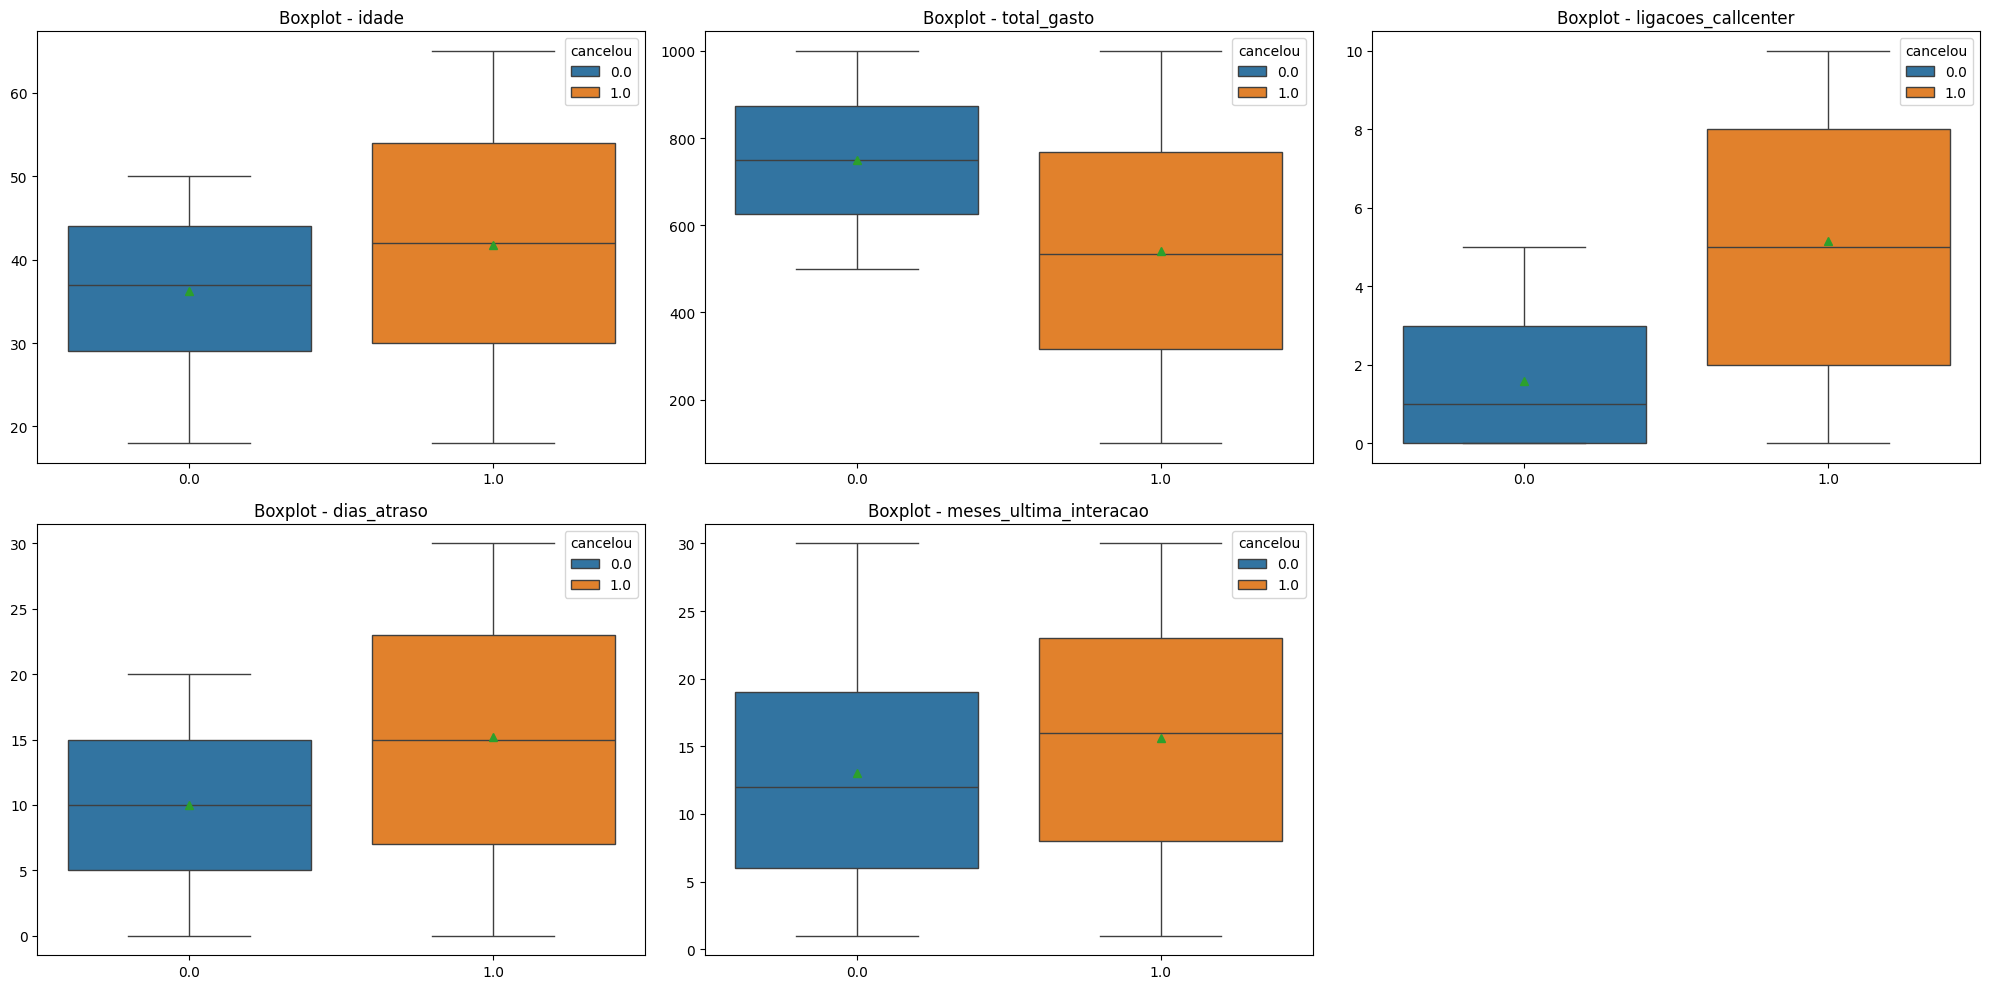

In [20]:
for i in hue_columns:

    print('- Gráfico: Diagrama de Caixa.\n')

    print(f'- Hue Column: {i}.')

    fn_charts_pandas.boxplot(df, eval(f'columns_{i}'), i, i)

    plt.savefig(f'../images/outputs/charts/pandas/nb04_boxplot_{i.lower()}.png', format = 'png', dpi = 75, bbox_inches = 'tight', transparent = True)

    plt.show()

### 04.3.8. Criando um mapa de calor para corroborar os insights encontrados nos histogramas

- Gráfico: Mapa de Calor.


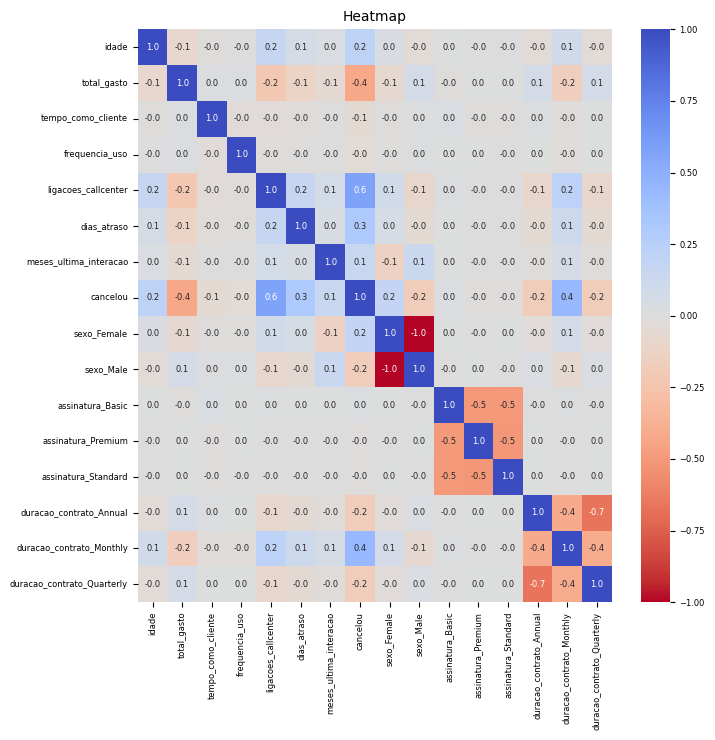

In [21]:
print('- Gráfico: Mapa de Calor.')

df_heatmap = pd.get_dummies(df).corr()

fn_charts_pandas.heatmap(df_heatmap)

plt.savefig(f'../images/outputs/charts/pandas/nb04_heatmap.png', format = 'png', dpi = 75, bbox_inches = 'tight', transparent = True)

plt.show()

### 04.3.9. Criando gráficos de barras para corroborar os insights encontrados nos histogramas e possivelmente gerando novos insights

- Gráfico: Gráfico de Barras.


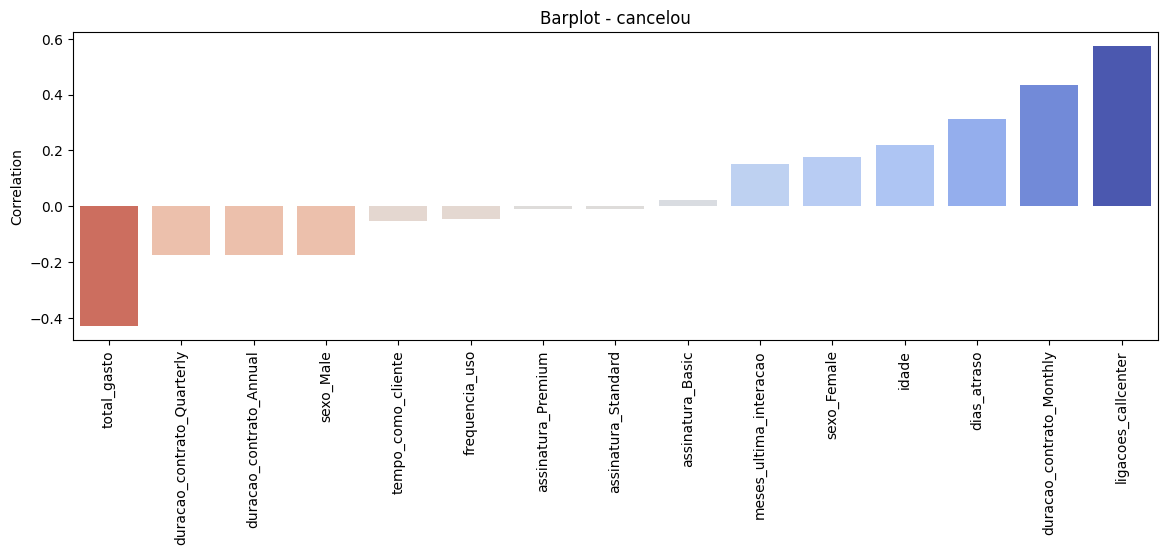

In [22]:
df_heatmap_unstack = (df_heatmap.unstack().rename('correlation').to_frame())

numeric_hue_columns = [hue_columns[i] for i in [0]]

for i in numeric_hue_columns:

    print('- Gráfico: Gráfico de Barras.')

    corr = df_heatmap_unstack.loc[i].sort_values('correlation')[:-1]

    fn_charts_pandas.barplot_correlation(corr, corr['correlation'], corr['correlation'].max(), i)

    plt.savefig(f'../images/outputs/charts/pandas/nb04_barplot_correlation_{i.lower()}.png', format = 'png', dpi = 75, bbox_inches = 'tight', transparent = True)

    plt.show()

## 04.4. Geração dos insights

### 04.4.1. Identificando os grupos de clientes com base na análise exploratória

| **Grupo 1**        | **Grupo 1**           | **Grupo 2**       | **Grupo 2**          |
|-----------------------------------|---------------------------------------|-----------------------------------|--------------------------------------|
| **Qualitativo**         | **Quantitativo**           | **Qualitativo**         | **Quantitativo**           |
| Mais de 50 anos                    | Idade > 50                 | Menos de 50 anos                    | Idade <= 50                     |
| Gastou menos de 500,00             | Gastos < 500               | Gastou mais de 500,00               | Gastos >= 500                   |
| Possui um contrato mensal          | Contrato = Mensal          | Possui contratos anual e trimestral | Contrato != Mensal              |
| Já ligou mais de 5 vezes no callcenter | Ligações Callcenter > 5    | Já ligou menos de 5 vezes no callcenter | Ligações Callcenter <= 5         |
| Atrasa o pagamento em mais de 20 dias | Dias de Atraso > 20        | Não atrasa o pagamento em mais de 20 dias | Dias de Atraso <= 20           |
| Fica mais de 15 meses sem interação | Meses sem Interação > 15   | Fica menos de 15 meses sem interação | Meses sem Interação <= 15        |

### 04.4.2. Verificando o percentual de conversão da campanha inicialmente

- Agrupamento da coluna: cancelou


cancelou,Percentage,Count
0.0,43.3,190833
1.0,56.7,249999


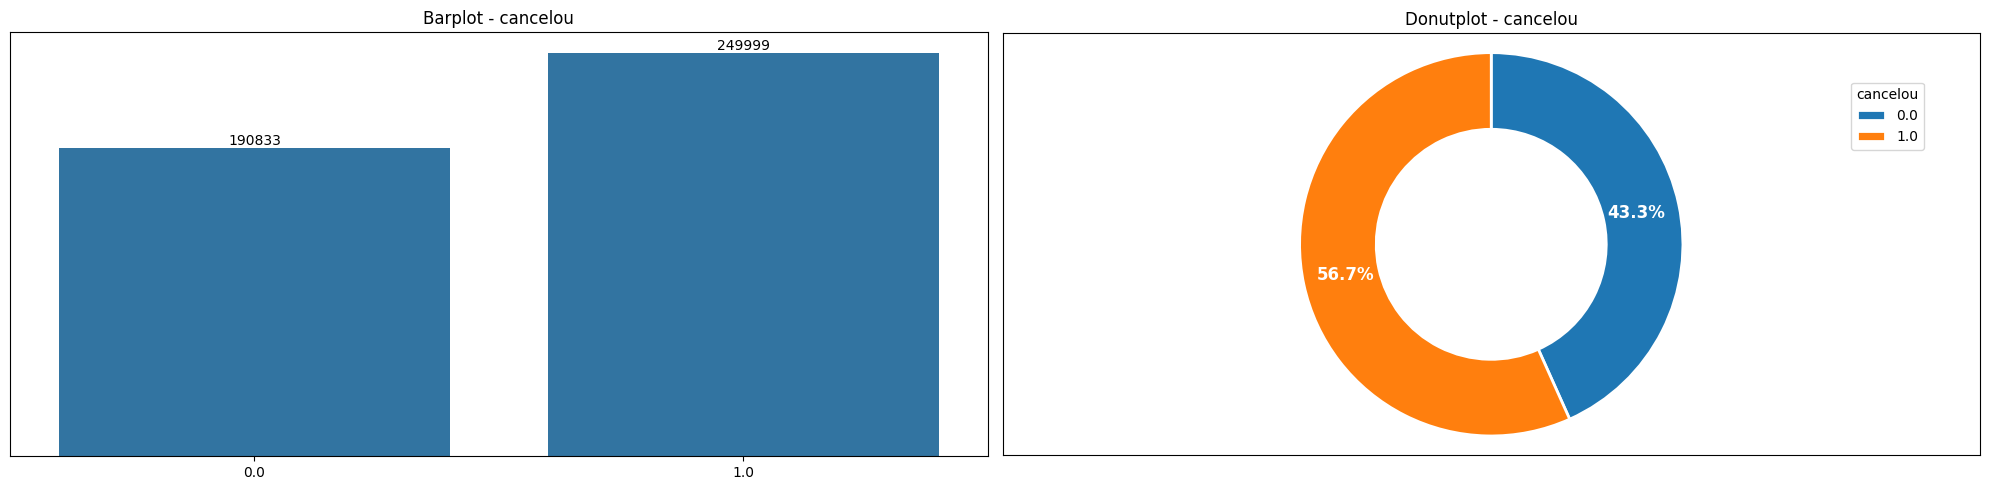

In [23]:
df_agg = fn_stats_pandas.groupby_count(df, 'cancelou')

print(f'- Agrupamento da coluna: cancelou')

display(HTML(df_agg.to_html(index = False)))

fn_charts_pandas.barplot_donutplot(df_agg, 'cancelou', 'Count')

plt.savefig(f'../images/outputs/charts/pandas/nb04_barplot_donutplot_cancelou_v1.png', format = 'png', dpi = 75, bbox_inches = 'tight', transparent = True)

plt.show()

### 04.4.3. Atualizando o dataset de acordo com o grupo mais propenso a aceitar campanhas

In [24]:
df = df[df['idade'] <= 50]

df = df[df['total_gasto'] >= 500]

df = df[df['assinatura'] != 'Mensal']

df = df[df['ligacoes_callcenter'] <= 5]

df = df[df['dias_atraso'] <= 20]

df = df[df['meses_ultima_interacao'] <= 15]

### 04.4.4. Verificando o percentual de conversão da campanha de acordo com o grupo mais propenso a aceitar campanhas

- Agrupamento da coluna: cancelou


cancelou,Percentage,Count
0.0,92.0,127032
1.0,8.0,11089


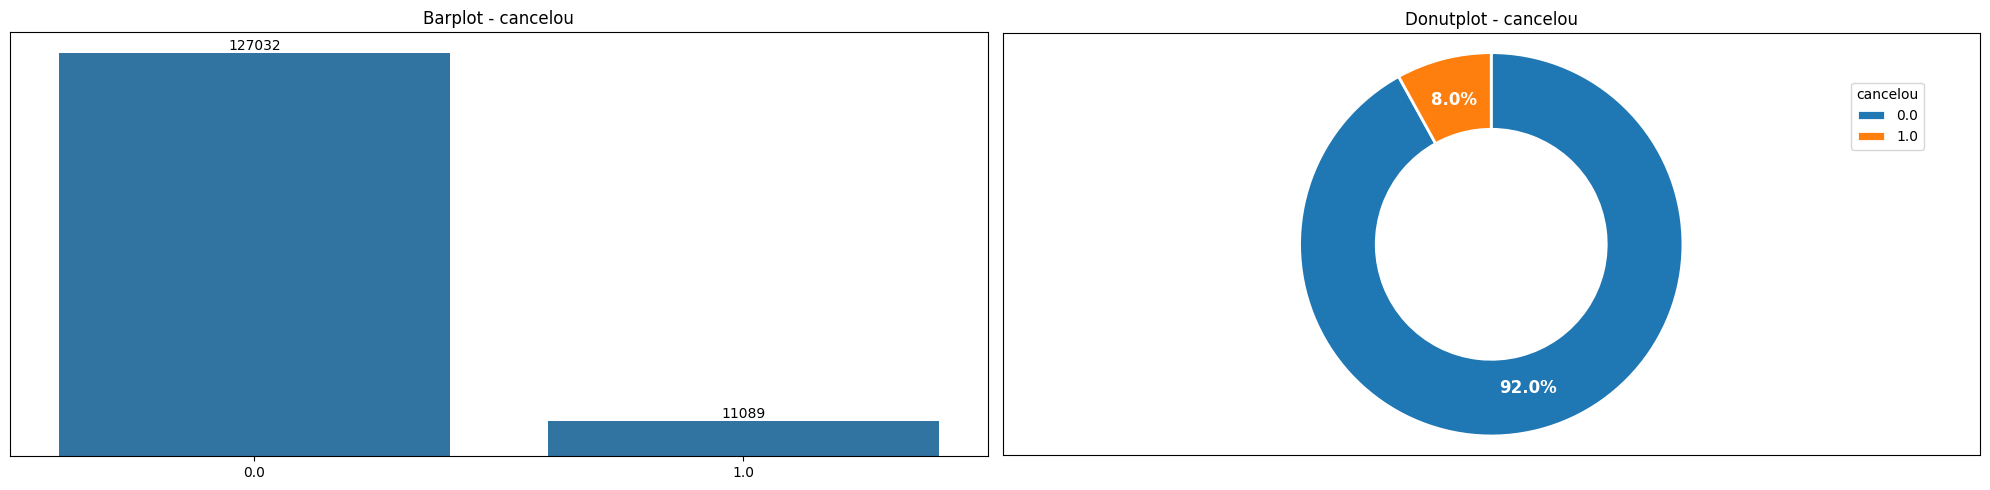

In [25]:
df_agg = fn_stats_pandas.groupby_count(df, 'cancelou')

print(f'- Agrupamento da coluna: cancelou')

display(HTML(df_agg.to_html(index = False)))

fn_charts_pandas.barplot_donutplot(df_agg, 'cancelou', 'Count')

plt.savefig(f'../images/outputs/charts/pandas/nb04_barplot_donutplot_cancelou_v2.png', format = 'png', dpi = 75, bbox_inches = 'tight', transparent = True)

plt.show()

### 04.4.5. Exibindo o dataset de acordo com o grupo mais propenso a aceitar campanhas

In [26]:
df.head(5)

,idade,sexo,total_gasto,assinatura,duracao_contrato,tempo_como_cliente,frequencia_uso,ligacoes_callcenter,dias_atraso,meses_ultima_interacao,cancelou
17,39.0,Female,577.0,Basic,Monthly,43.0,2.0,4.0,15.0,6.0,1.0
61,42.0,Male,736.0,Premium,Monthly,29.0,23.0,0.0,6.0,5.0,1.0
85,45.0,Female,699.0,Premium,Quarterly,23.0,4.0,5.0,1.0,12.0,1.0
95,32.0,Male,649.0,Basic,Annual,13.0,6.0,4.0,11.0,8.0,1.0
112,46.0,Female,672.0,Standard,Monthly,8.0,30.0,0.0,9.0,10.0,1.0


### 04.4.6. Comentando os insights e o potencial de impacto da análise exploratória dos dados

Após realizar o estudo de acordo com o grupo mais propenso a manter sua assinatura conforme extraído pelos insights dessa análise exploratória dos dados, estimamos a evolução da coluna target (cancelou). 

Essa coluna cancelou corresponde a quantidade de clientes que cancelaram a assinatura com a empresa. 

Como resultado, inicialmente tínhamos um total de cancelamentos de clientes de **56,7%** e após focar o estudo no grupo de clientes mais propenso a manter sua assinatura o total de cancelamentos foi para **8,0%**, representando assim uma **redução de 48,7%**.

O resultado encontrado foi excelente, onde **houve uma redução expressiva no índice de churn das assinaturas**. O único ponto de ressalva é que foram aplicadas condições para se chegar a esse resultado, deixando assim o número de clientes mais restrito. Dessa forma, é preciso discutir com a área de Negócios para estabelecer se esse resultado atende as necessidades da área ou é preciso fazer ajustes, como por exemplo reduzir o número de parâmetros para que a campanha possa atingir um número maior de clientes.